---
# Computergestützte Datenauswertung
**Institut für Experimentelle Teilchenphysik (ETP)** <br>
**Institut für Theorie der Kondensierten Materie (TKM)** <br>
Prof. Dr. Jan Kieseler (ETP), Dr. Joscha Ahäuser (ETP) <br>
Dr. Thorsten Chwalek (ETP), Dr. Andreas Poenicke (TKM) <br>
[ILIAS-Seite zum Kurs](https://ilias.studium.kit.edu/ilias.php?baseClass=ilrepositorygui&cmdNode=xs:mo&cmdClass=ilobjcoursegui&ref_id=2891557&item_ref_id=0) <br>
Sommersemester 2026 – Blatt 01 <br>
Abgabe: Montag, 4.05.2026 & Dienstag, 5.05.2026 

---

Werbung 

![RocketScience](RocketScience.png)

Werbung Ende 

Auf dem ersten echten Übungsblatt setzen Sie sich mit den Bibliotheken *NumPy* und *Matplotlib* auseinander und werten ein Würfelspiel aus. 
Die [erste Aufgabe](#Aufgabe1) bietet die Möglichkeit, die sehr viel verwendete *Python*-Bibliothek *NumPy* kennenzulernen und den Einsatz von elementweisen Vektoren und die Erzeugung von Zufallszahlen zu üben.
In der [zweiten Aufgabe](#Aufgabe2) beschäftigen Sie sich mit der Visualisierung von "gemessenen" Daten und der Vergleich zu der entsprechenden Erwartung.
Die [letzte Aufgabe](#Aufgabe3) behandelt ein Zufallsexperimente mit Würfeln.


---
# Aufgabe 1: Datenauswertung: *NumPy* <a id="Aufgabe1"></a>
---
Vieles lässt sich bereits mit dem Standardbefehlssatz von *Python* erreichen.
Im Bereich der Datenauswertung hat sich jedoch die Bibliothek [*NumPy*](https://numpy.org/devdocs/user/index.html) zu einem Standard entwickelt, da diese nicht nur zusätzliche Funktionen bietet, sondern auch gerade bei größeren Datenmengen deutlich schneller arbeitet.
Funktionen - wie die Fakultät - müssen Sie in der Zukunft selten selbst implementieren, schauen Sie bei üblichen mathematischen Funktionen erst nach, ob diese nicht bereits in *NumPy* oder *SciPy* definiert wurden.

Einen weitere wichtige Anwendung von *NumPy* haben Sie bereits in der Vorlesung kennengelernt: Die Erzeugung von (Pseudo-) Zufallszahlen. 

**Arbeitsanweisung:**<br>
Ziel dieser Aufgabe ist es, Ihr eigenes kleines Zufallsexperiment zu schreiben.
Simulieren Sie hierzu den Wurf eines Würfels mit den Augenzahlen $\{1, \dots,6\}$ insgesamt 10 Mal.
Übeberlegen Sie sich, wie wahrscheinlich jeder Wert auftreten kann und welche Verteilung von Zufallszahlen Sie hierfür benötigen. 
Speichern Sie die Häufigkeit jeder Augenzahl in einem `numpy.array` und lassen Sie sich die Werte ausgeben. 
Wiederholen Sie Ihre Simulation mit 100 bzw. 1000 Würfen. 
Erhalten Sie das erwartete Ergebnis?

**Hinweise:**<br>
1. Die *NumPy*-Bibliothek (und viele weitere Bibliotheken) ist bereits auf dem *Jupyter*-Server installiert. Die übliche Weise, *NumPy* in Ihren *Python*-Skripten (und *Jupyter*-Notebooks) aufzurufen, ist wie folgt:
    ```python
    import numpy as np
    ```
    Anschließend können Sie auf jede Funktionalität mit `np` zugreifen, bspw.:
    ```python
    a = np.array([1, 2, 3])
    ```
2. Erzeugen Sie mit `numpy.random.default_rng()` einen Standard-Zufallszahlengenerator. Suchen Sie für die Erzeugung der Zufallszahlen eine passende Funktion in der Dokumentation von [`numpy.random.Generator`](https://numpy.org/doc/stable/reference/random/generator.html#simple-random-data) aus oder verwenden Sie die Ihnen aus der Vorlesung bekannten Beispielfunktionen.

In [1]:
# Importieren von numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from enum import Enum, auto

class GameConst(Enum):
    """
    Introduces all necessary values for playing a dice game.
    """
    DICES = 3
    DICE_SIDES = 6
    THROWS = int(1e3)
    RES_SPECTRUM = range(1*DICES, DICE_SIDES*DICES+1)
    PLAYER = 2

class DiceGameUtilities:
   """
   Helper class that stores all functions that are tied in a sense to the dice game.
   """

def compute_eyesum_frequency(dice_res:list, res_spectrum) -> list:
    """
    Compute the total amount of the corresponding eye sum.

    Args
    ----
    dice_res (list) : container taht stores the eyesum of each row
    res_spectrum (iterable) : defines allowed range for dice results, which is determined by  the number of used dices per throw and the sides number of the dice.

    Returns
    -------
    (list) : contains the frequency contributing for each allowed eyesum
    """
    return [np.sum(dice_res == k) for k in res_spectrum]

"""def dice_game_simulator(dice_sides, dices, throws, players):

    Simulate the dice game. During a round all players make one throw with a fixed number of dices.
    The game itself goes throws rounds.
    ARGS
    ----
    "--"
    PARAMS
    ------
    "--"

    rng = np.random.default_rng()
    [rng.integers(low=1*dices, high=dice_sides*dices+1, size=throws) for _ in range(players)]
    return [rng.integers(low=1*dices, high=dice_sides*dices+1, size=throws) for _ in range(players)]"""

def dice_game_simulator(dice_sides:int, dices:int, throws:int, players:int)->tuple[np.array, np.array]:
    """
    Simulate the dice game. During a round all players make one throw with a fixed number of dices.
    The game itself goes throws rounds.
    ARGS
    ----
    "--"
    Returns:
    (np.arrya) : tuple containing two collections that stores the raw sum of the dices and on estores the mean of each row (1 throw with n dices)
    "--"
    """
    rng = np.random.default_rng()
    raw = np.array([rng.integers(low=1*dices, high=dice_sides*dices+1, size=throws) for _ in range(players)])
    return raw, np.asarray(raw/dices, dtype=float)


2
2


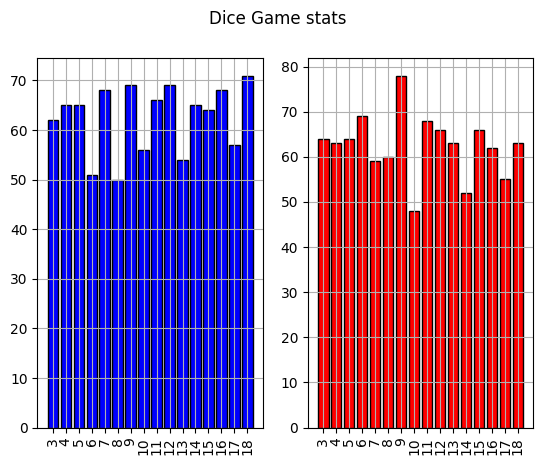

Player B won 434 rounds during the game with 927 effective total rows


In [3]:
#start the game
results, _ = dice_game_simulator(GameConst.DICE_SIDES.value, GameConst.DICES.value, GameConst.THROWS.value, GameConst.PLAYER.value)

eyesum_frequencies = list()

for res in results:
    eyesum_frequencies.append(compute_eyesum_frequency(res, GameConst.RES_SPECTRUM.value))

print(len(eyesum_frequencies))

#actually dependent of number of players but we want just the first two here.
print(len(eyesum_frequencies))
x1 = eyesum_frequencies[0]
x2 = eyesum_frequencies[1]

y = GameConst.RES_SPECTRUM.value

#plot the results of the game.
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Dice Game stats")

#plot the actual data
ax1.bar(y, x1, color="blue", label="Player 1", edgecolor="black")
ax1.set_xticks(GameConst.RES_SPECTRUM.value, labels=GameConst.RES_SPECTRUM.value, rotation=90)

#way to have a legend for the whole figure
ax2.bar(y, x2, color="red", label="Player 2", edgecolor="black")
ax2.set_xticks(GameConst.RES_SPECTRUM.value, labels=GameConst.RES_SPECTRUM.value, rotation=90)

ax1.grid()
ax2.grid()


plt.show()

same_res = np.sum(x1==x2)
effective_rounds = GameConst.THROWS.value - same_res

player_a_won = np.sum(x1>x2) >= (effective_rounds)/2
player_b_won = not player_a_won

if np.sum(x1>x2) == (effective_rounds)/2:
    player_b_won = True

a = np.array(results[0])
b = np.array(results[1])

if player_a_won ^ player_b_won:
    print("Player {message} won {r} rounds during the game with {t} effective total rows".format(message="A" if player_a_won else "B", r = np.sum(a>b) if player_a_won else np.sum(b>a), t = GameConst.THROWS.value-np.sum(a==b)))
else:
    print("Its a draw, enter next round to find a winner.")


In [2]:
# Aufzählen der Häufigkeit


---
# Aufgabe 2: Darstellungen von Daten: *Matplotlib* <a id="Aufgabe2"></a>
---
Ein wichtiger Schritt bei der Datenauswertung ist die Visualisierung der Daten. 
Durch die Bibliothek [*Matplotlib*](https://matplotlib.org/stable/tutorials/index) steht Ihnen hierzu ein mächtiges Werkzeug zur Verfügung, welches auch oft in Kombination mit *NumPy* verwendet wird.

**Arbeitsanweisung:**<br>
Simulieren Sie in den **folgenden Zellen** gemäß der zugehörigen Anleitung eine Datennahme von "Messwerten", die einer Parabel $f(x)=x^2$ folgen. 
Stellen Sie anschließend das Ergebnis geeignet dar. 
Die Darstellung soll die "Messwerte" inklusive deren Unsicherheiten sowie das vorausgesagte Modell enthalten.

**Anmerkung:**<br>
Ähnliche Problemstellungen, also der Vergleich von Daten mit einer Modellfunktion, treten in der Datenauswertung sehr häufig auf. 
Es lohnt sich daher, an Ihrem Code sehr sorgfältig zu arbeiten, damit Sie ihn oder Teile davon später weiter verwenden können. 
Sie erhalten hier Ihr eigenes, flexibles Grafikwerkzeug für den Vergleich von Daten mit Modellen, auf das Sie immer wieder zurückgreifen können.

In [4]:
# Importieren der benötigten Module
import numpy as np
import matplotlib.pyplot as plt

Berechnen Sie zunächst die Parabel $f(x)=x^2$ im Wertebereich $x \in [0, 5]$ für 1000 $x$-Werte. 

**Hinweise:**<br>
1. Zur Erstellung der $x$-Werte können Sie die Funktion [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) verwenden. 
2. Beachten Sie, dass Exponenten in *Python* mit `**` angegeben werden (z.B. `2**3=8`)

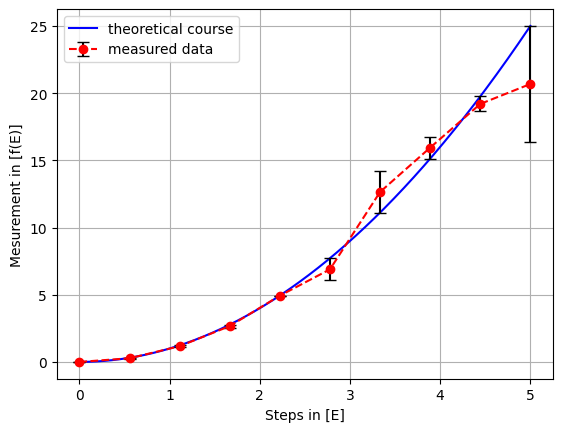

In [5]:

"""Create a data set that is coming from a fictive experiment which values are not exact.
To include that the values are not exact adjust the exact output with a uncertainty. x + u = y
"""
from enum import Enum
class SimConst(Enum):
    LOWER_BOUND = 0
    UPPER_BOUND = 5
    STEPS_COMP = 1000
    STEPS_EXP = 10

#rule for comparison data - gained from theory
my_func = lambda x: x**2

#define the domain of the values
x_values_comp = np.linspace(SimConst.LOWER_BOUND.value, SimConst.UPPER_BOUND.value, SimConst.STEPS_COMP.value)

x_values_exp = np.linspace(SimConst.LOWER_BOUND.value, SimConst.UPPER_BOUND.value, SimConst.STEPS_EXP.value)

#define comparison values
comparison = [my_func(x) for x in x_values_comp]

#create a gaussian normal distribution number generator to get an uncertainty for the fictive experimental data.

rng = np.random.default_rng()
adjustments = rng.normal(loc=0, scale=0.1, size=SimConst.STEPS_EXP.value) #loc=mean of distribution, scale=deviation, uncertainty

#create the data from the fictive experiment using the adjustments gained from gausian normal distribution
raw_data = np.array([my_func(k) for k in x_values_exp])
experiment_data =raw_data + raw_data*adjustments

#plot the graph

fig, ax = plt.subplots(1, 1)

ax.plot(x_values_comp, comparison, color="blue", label="theoretical course")

ax.errorbar(x_values_exp, experiment_data,yerr=np.abs(raw_data*adjustments), fmt="ro--", ecolor="black", capsize=4, label="measured data")

ax.set_xlabel("Steps in [E]")
ax.set_ylabel("Mesurement in [f(E)]")

ax.grid()
ax.legend()
plt.show()



In [ ]:
# Definition von y=x^2


Erzeugen Sie "Messwerte" für $x \in \{1, 2 ,3 ,4\}$, die jeweils dem Wert $f(x)$ mit einer normalverteilten (auch: gaußförmigen) Unsicherheit von $10 \%$ des wahren Werts entsprechen. 
Erzeugen Sie hierfür ein *NumPy*-Array mit vier Zufallszahlen aus einer Standard-Normalverteilung. 
Wenn Sie diese Werte mit der gewünschten Unsicherheit (also $0.1\cdot x^2$) multiplizieren, erhalten Sie die Zufallskomponente eines jeden Datenpunktes, die Sie zu den berechneten $y$-Werten addieren.

**Hinweise:**<br>
1. Suchen Sie erneut für die Erzeugung der Zufallszahlen eine passende Funktion in der Dokumentation von [`numpy.random.Generator`](https://numpy.org/doc/stable/reference/random/generator.html#distributions) aus.
2. Anmerkung: Für besonders kurzen (und übersichtlichen) Code nutzen Sie die elementweise Vektorisierung von *NumPy* aus. Z.B.: 
    ```python
    a = np.array([1, 2, 3])
    b = a + a # bzw. b = 2*a
    print(b) # Ausgabe: array([2, 4, 6])
    ```

In [ ]:
# Erstellen der Datenpunkte


Stellen Sie nun das Ergebnis in einem Plot dar. 
Zeigen Sie die erwartete Parabel als eine Linie und die erzeugten "Messwerte" als Kreise mit Fehlerbalken. 
Denken Sie ebenfalls an das Hinzufügen von Achsenbeschriftungen und einer Legende. 

**Hinweise:**<br>
1. Im Allgemeinen werden Sie einen Großteil der einfachen Darstellungen mithilfe von [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) erledigen können.
2. Fehlerbalken können am einfachsten mit [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) dargestellt werden.
3. Geben Sie den Darstellungsfunktionen (`plt.plot`, `plt.errorbar`,...) jeweils ein `label`-Parameter mit, welcher in der Legende dargestellt wird.
4. Machen Sie sich mit [`plt.xlabel`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html), [`plt.ylabel`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylabel.html) und [`plt.legend`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html) vertraut.

In [ ]:
# Darstellung in einem Plot inkl. Achsenbeschriftung und Legende


---
# Aufgabe 3: Würfelspiel <a id="Aufgabe3"></a>
---
In dieser Aufgabe führen Sie Zufallsexperimente mit Würfeln aus.
Sie werfen jedes Mal $n$ Würfel gleichzeitig und betrachten die resultierende Augensumme.
Ziel dieser Aufgabe ist es, das Durchführen und grafische Darstellen von Zufallsexperimenten zu vertiefen.

Sie können folgende Funktion für die Simulation eines Würfelergebnisses mit drei Würfeln verwenden.
Sie erhalten beim Ausführen der `dice()` Funktion die drei gewürfelten Augenzahlen.

In [ ]:
"""import numpy as np

rng = np.random.default_rng(42)

def dice():
    # Wurf von 3 Würfeln
    return rng.integers(low=1, high=7, size=3)"""

**Arbeitsanweisung:**<br>
Zunächst spielen Sie mit 3 Würfeln.
Summieren Sie für jeden Wurf mit 3 Würfeln die Augensumme $S$ der Würfel.
Führen Sie 1000 solcher Spiele durch und stellen Sie die Häufigkeitsverteilung der Augensumme $S$ grafisch dar.

**Hinweis:**<br>
Verwenden Sie gerne die Funktion [`matplotlib.pyplot.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) zur Darstellung der Häufigkeit der verschiedenen Augensummen.
Eine sehr einfach Verwendung der Funktion ist, `plt.hist(a, b)` in der `a` das Array ist, welches all die Aufgensummen enthält, und `b` das Binning vorgibt. 
Geben Sie beispielsweise eine Integerzahl für `b` ein, so werden `b` Bins zur Darstellung verwendet.
Überlegen Sie sich, wie viele Bins sie für alle möglichen Augensummen Ergebnisse mit 3 Würfeln benötigen würden.

*Anmerkung*: Sie können auch eine Liste oder ein `numpy.array` mit $n_\mathsf{bins}+1$ Einträgen als `b` übergeben. Diese werden als die Bingrenzen interpretiert.

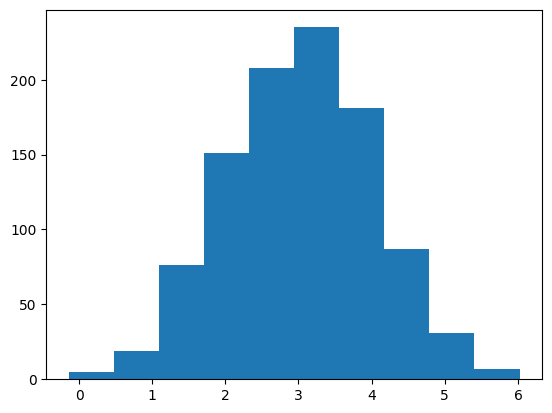

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import math

# available construct from task 1
"""
DiceGameUtilities
-compute_eyesum_frequency
-dice_game_simulator

GameConst
"""

rng = np.random.default_rng()
val = rng.normal(loc=3, scale=1, size=1000)
#print(val)

fig, ax = plt.subplots(1, 1)
ax.hist(val)
plt.show()



In [3]:
# Durchführen des Zufallsexperiments:
# 3 Würfel, 1000 Mal geworfen
eye_sums, _ = dice_game_simulator(GameConst.DICE_SIDES.value, GameConst.DICES.value, GameConst.THROWS.value, 1)
freq = compute_eyesum_frequency(np.array(eye_sums), GameConst.RES_SPECTRUM.value)

#using a histogram to display the probabilities gained from one simulation of the dice game
#we use the res_spectrum itself rather than using the amount of bins defined by b = GameConst.DICE_SIDES.value * GameConst.DICES.value - (GameConst.DICES.value-1)
#plt.hist(freq, list(GameConst.RES_SPECTRUM.value), density=True, label="eye sum frequency", edgecolor="black")

dice_sides = 6
bins = 3*6 - 3 #there is no 0 on the dice

#dice_results = [np.sum(dice(tot_dices=3)) for _ in range(0, 1000)]

#bin_values = [filter_amount(dice_results, k) for k in range(3, 19, 1)]

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.bar(GameConst.RES_SPECTRUM.value, freq, label='eye_sums tot. number')
ax1.set_xticks(GameConst.RES_SPECTRUM.value,labels=GameConst.RES_SPECTRUM.value, rotation=90)
ax1.set_xlabel("eye sum")
ax1.set_ylabel("frequency")
ax1.legend()
ax1.grid()

"""
#plot a histogram that displays the varying frequencies of the possible eye sums (probability density)


# bins 3-6, 7-10, 11-14, 15-18
# centers: 4.5, 8.5, 12.5, 16.5...
#values groupe he eye sum values in such that they embrace a spectrum of exactly three different values
#ax2.hist(bin_values, 4, label="eye sum probability")

bin_centers = [4*k + 0.5 for k in range(1,5)]
bin_labels=[f"{3+4*k} to {6+4*k}" for k in range(0, 4)]
#print(bin_centers)"""

#histogramm does not need the predefined values it can map a iterable that stores abitrary values so the same values will be pared.
density_values, _, _ = ax2.hist(list(eye_sums), bins=16, edgecolor="black", density=True ,label='eye_sum probability')
ax2.set_xticks(GameConst.RES_SPECTRUM.value, labels=GameConst.RES_SPECTRUM.value, rotation=90)

ax2.legend()
ax2.grid()
plt.show()

#print(np.sum(density_values))

NameError: name 'dice_game_simulator' is not defined

In [ ]:
# Grafische Darstellung des Ergebnisses


Verallgemeinern Sie Ihren Code oder die oben angegebene Funktion so, dass Sie auch mit einer beliebigen Zahl von <mark>$n$ Würfeln gleichzeitig $N$ Spiele</mark> spielen können.
Berechnen Sie nun anstelle der Augensumme die <mark>mittlere Augensumme $\bar{s}=S/n$ </mark>und geben Sie für alle $N$ Spiele die mittlere Augensumme $\bar{s}$ in der neuen Funktion aus.
Stellen Sie anschließend die Häufigkeitsverteilung der mittleren Augenzahl für $n=10$, $n=50$ und $n=100$ für jeweils $N=1000$ Spiele dar.

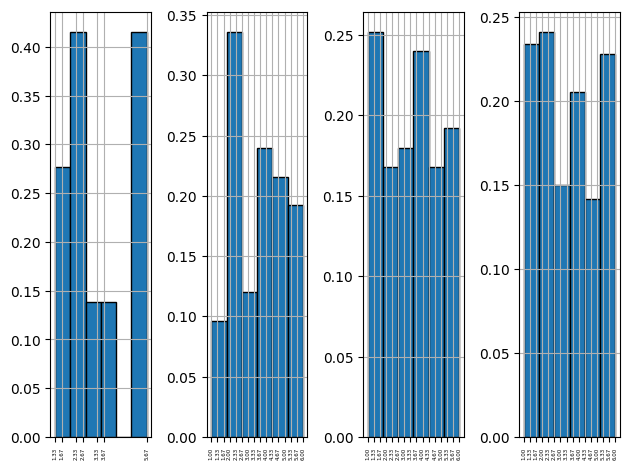

In [6]:
throws = [10, 50, 100, GameConst.THROWS.value]
amount_of_dices = [GameConst.DICES.value]
num_bins = math.ceil((GameConst.DICES.value * GameConst.DICE_SIDES.value)/GameConst.DICES.value - GameConst.DICES.value/GameConst.DICES.value) + 1

eye_sums_mean = list()
#lop through the wished number of throws per game which is called N.
for N in throws:
    _, eye_sum_mean = dice_game_simulator(GameConst.DICE_SIDES.value,
                                          GameConst.DICES.value,
                                          N,
                                          1)
    eye_sums_mean.append(eye_sum_mean)
    #print(eye_sum_mean)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)
for ax, val, n in zip((ax1, ax2, ax3, ax4), eye_sums_mean, throws):
    #label=f'total throws per round {n}'
    bin_labels = list(set(val.tolist()[0]))
    ax.hist(list(val), bins=num_bins, label=f'throws per round {n}', edgecolor='black', density=True)
    ax.set_xticks(bin_labels, labels= [f"{x:.2f}" for x in bin_labels], rotation=90)
    ax.tick_params(axis='x' ,labelsize=4)
    #print(bin_labels)
    #ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()





gethrows = [GameConst.THROWS.value]
amount_of_dices = [GameConst.DICES.value, 5, 100]

eye_sums_mean = list()
#lop through the wished number of throws per game which is called N.
for N in throws:
    for num_dices in amount_of_dices:
        _, eye_sum_mean = dice_game_simulator(GameConst.DICE_SIDES.value,
                                          num_dices,
                                          N,
                                          1)
        eye_sums_mean.append(eye_sum_mean)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
for ax, val, num_dices in zip((ax1, ax2, ax3), eye_sums_mean, amount_of_dices):
    #label=f'total throws per round {n}'
    bin_labels = [k/num_dices  for k in range(num_dices, GameConst.DICE_SIDES.value*num_dices)]
    num_bins = len(bin_labels)
    ax.hist(list(val), bins=num_bins, label=f'total throws per round {n}', edgecolor='black', density=True)
    ax.set_xticks(bin_labels, labels= [f"{x:.2f}" for x in bin_labels], rotation=90)
    ax.tick_params(axis='x' ,labelsize=4)
    ax.grid()

plt.tight_layout()
plt.show()


Wiederholen Sie nun die Zufallsexperimente mit $n=5$ und $n=100$ Würfel für $N=10000$ Spiele. 
Bestimmen Sie für beide Durchläufe jeweils die Stichprobenstandardabweichung und das arithmetische Mittel und zeichnen Sie eine Normalverteilung mit den ausgerechneten Werten mit in das Histogramm.
Was beobachten Sie für die jeweilige Würfelanzahl?

**Hinweise:**<br>
1. eine Funktion, die die Normalverteilung implementiert, ist in der folgenden Zelle gegeben. Wenn Sie die Verteilung mit dem Histogramm zusammen darstellen wollen, müssen Sie entweder das Histogramm normieren (fügen Sie folgende Option hinzu zur Darstellung vom Histogramm: `plt.hist(..., density=True)`) oder die Darstellung der Normalverteilung.
2. Wiederholen Sie die Zufallsexperimente gerne einige Mal durch mehrfaches Ausführen der Zelle, um den Unterschied zu beobachten.

In [64]:
# Funktion für die Normalverteilung
def Gaussian(x, mu=0., sigma=1.):
    return np.exp(-(x - mu)**2 / 2 / sigma**2) / np.sqrt(2*np.pi) / sigma

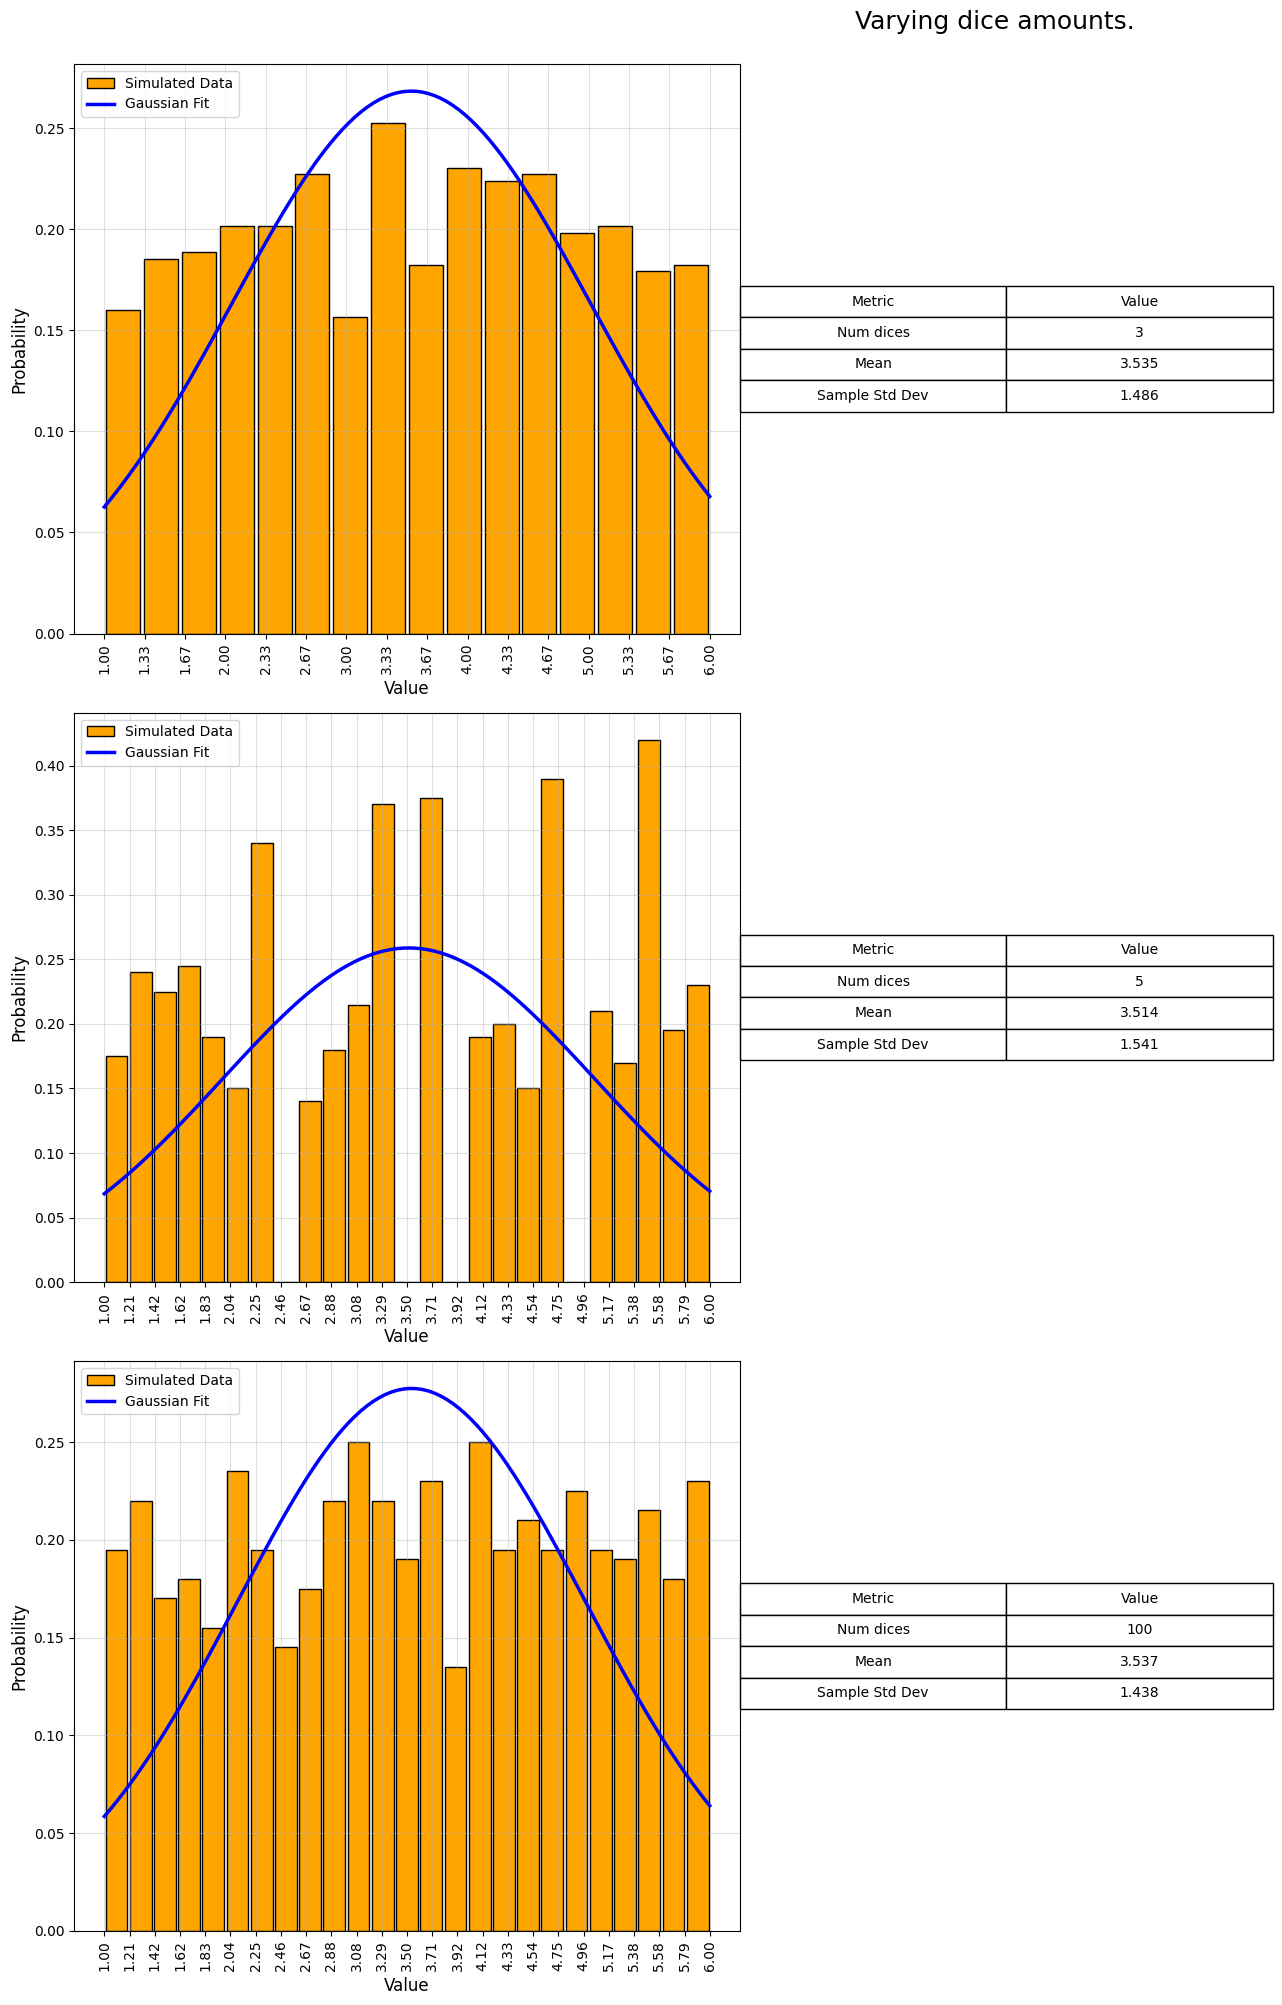

In [76]:
"""throws = [GameConst.THROWS.value]
amount_of_dices = [GameConst.DICES.value, 5, 100]

eye_sums_mean = list()
bin_labels = list()
max_amount_bins = 25

#Use different values for throws per round N and different number of dices.
for N in throws:
    for num_dices in amount_of_dices:
        #create the game data
        _, eye_sum_mean = dice_game_simulator(GameConst.DICE_SIDES.value,
                                          num_dices,
                                          N,
                                          1)
        eye_sums_mean.append(eye_sum_mean)

        #create bins
        bin_label = [k/num_dices  for k in range(num_dices, GameConst.DICE_SIDES.value*num_dices + 1)]

        if len(bin_label) > max_amount_bins:
            bin_label = np.linspace(1, GameConst.DICE_SIDES.value, 25)

        bin_labels.append(bin_label)

#Plot the differet results for the varying number of game dices
fig, ((ax1), (ax2), (ax3)) = plt.subplots(3, 1)

#Customize the figure in which the axes live.
fig.suptitle("Varying dice amounts.", y=1 ,fontsize=18)
fig.set_size_inches(20, 20)
fig.tight_layout()

for ax, val, num_dices, bin in zip((ax1, ax2, ax3), eye_sums_mean, amount_of_dices, bin_labels):

    #statistics
    am = np.mean(val)
    ssd = np.std(val)

    #place information in the axis
    info_text = f"Dices: {num_dices}\nAM: {am}\nSSD: {ssd}\n"
    ax.text(1.05, 0.95, info_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))


    #plot
    ax.hist(list(val), bins=len(bin), label=f"Used dices: {num_dices}", edgecolor='black', rwidth=0.9, color="orange", density=True)
    ax.set_xticks(bin, labels= [f"{x:.2f}" for x in bin], rotation=90)
    ax.set_aspect('auto')
    ax.grid()
    ax.legend(loc="upper left", fontsize=12)
    ax.set_xlabel("Value", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)



    am = np.mean(val)
    ssd = np.std(val)

    print(f"Arithmetic mean: {am}, sample standard deviation: {ssd}")
#plt.subplots_adjust()

plt.tight_layout()
plt.show()
"""

"""throws = [GameConst.THROWS.value]
amount_of_dices = [GameConst.DICES.value, 5, 100]

eye_sums_mean = list()
bin_labels = list()
max_amount_bins = 25

#Use different values for throws per round N and different number of dices.
for N in throws:
    for num_dices in amount_of_dices:
        #create the game data
        _, eye_sum_mean = dice_game_simulator(GameConst.DICE_SIDES.value,
                                          num_dices,
                                          N,
                                          1)
        eye_sums_mean.append(eye_sum_mean)

        #create bins
        bin_label = [k/num_dices  for k in range(num_dices, GameConst.DICE_SIDES.value*num_dices + 1)]

        if len(bin_label) > max_amount_bins:
            bin_label = np.linspace(1, GameConst.DICE_SIDES.value, 25)

        bin_labels.append(bin_label)

rng = np.random.default_rng()

#Plot the differet results for the varying number of game dices
fig, ((ax1), (ax2), (ax3)) = plt.subplots(3, 1)

#Customize the figure in which the axes live.
fig.suptitle("Varying dice amounts.", y=1 ,fontsize=18)
fig.set_size_inches(20, 20)
#fig.tight_layout()

for ax, val, num_dices, bin in zip((ax1, ax2, ax3), eye_sums_mean, amount_of_dices, bin_labels):

    #statistics
    am = np.mean(val)
    ssd = np.std(val)

    comparison = rng.normal(loc=am, scale=ssd, size=GameConst.THROWS.value)
    ax.hist(comparison, density=True, color="blue")

    #place information in the axis
    table_data = [["Num dices",
                  f"{num_dices}"],
                  ["Mean",
                  f"{am:.3f}"],
                  ["Sample Std Dev",
                  f"{ssd:.3f}"]]

    #adding the table to the axis
    my_table = ax.table(cellText=table_data,
                        colLabels=["Metric", "Value"],
                        loc='right',
                        cellLoc='center')

    my_table.scale(0.8, 1.5)

    #plot
    ax.hist(list(val), bins=len(bin),
            edgecolor='black', rwidth=0.9,
            color="orange", density=True)
    ax.set_xticks(bin, labels= [f"{x:.2f}" for x in bin], rotation=90)
    ax.set_aspect('auto')
    ax.grid()
    ax.set_xlabel("Value", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)

#plt.subplots_adjust()

plt.tight_layout()
fig.tight_layout()
plt.show()
"""

rng = np.random.default_rng()

# Plot the different results for the varying number of game dices
fig, ((ax1), (ax2), (ax3)) = plt.subplots(3, 1)

# Customize the figure in which the axes live.
fig.suptitle("Varying dice amounts.", y=1 ,fontsize=18)
fig.set_size_inches(20, 20)

# Note: I renamed the loop variable from 'bin' to 'current_bins'
# so we don't accidentally overwrite Python's built-in bin() function!
for ax, val, num_dices, current_bins in zip((ax1, ax2, ax3), eye_sums_mean, amount_of_dices, bin_labels):

    # Statistics
    am = np.mean(val)
    ssd = np.std(val)

    # 1. Plot the actual simulated data
    ax.hist(list(val), bins=len(current_bins),
            edgecolor='black', rwidth=0.9,
            color="orange", density=True, label="Simulated Data")

    # 2. Plot the Gaussian Normal Distribution as a curve
    # Generate a smooth x-axis strictly bounded by current_bins
    x_min, x_max = min(current_bins), max(current_bins)
    x_axis = np.linspace(x_min, x_max, 100)

    # Plot the curve over the histogram
    ax.plot(x_axis, Gaussian(x_axis, mu=am, sigma=ssd), color="blue", linewidth=2.5, label="Gaussian Fit")

    # Place information in the axis
    table_data = [["Num dices", f"{num_dices}"],
                  ["Mean", f"{am:.3f}"],
                  ["Sample Std Dev", f"{ssd:.3f}"]]

    # Adding the table to the axis
    my_table = ax.table(cellText=table_data,
                        colLabels=["Metric", "Value"],
                        loc='right',
                        cellLoc='center')

    my_table.scale(0.8, 1.5)

    # Strictly enforce your defined bins and precision for the x-ticks
    ax.set_xticks(current_bins)
    ax.set_xticklabels([f"{x:.2f}" for x in current_bins], rotation=90)

    # Plot formatting
    ax.set_aspect('auto')
    ax.grid(alpha=0.4) # Slightly lighter grid so it doesn't visually clash with the orange bars
    ax.set_xlabel("Value", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()





